In [17]:
import torch
import torch.nn as nn
from torch.optim import SGD
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pip  install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [11]:
import tensorflow as tf
print(tf.__version__)  # Should print the TensorFlow version

2.19.0


In [18]:
from tensorflow.keras.datasets import mnist


In [19]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [20]:
y_test


array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [21]:
(x_train).shape


(60000, 28, 28)

In [22]:
y_train[2]

4

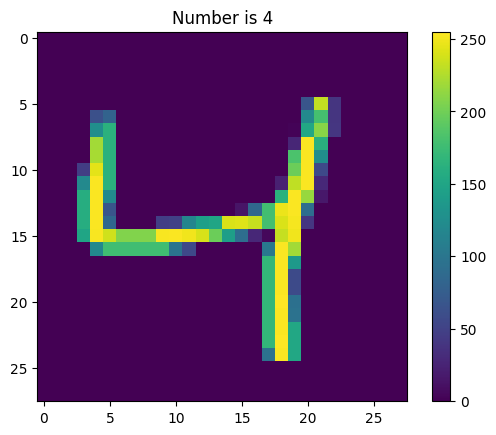

In [23]:
plt.imshow(x_train[2])
plt.title(f'Number is {y_train[2]}')
plt.colorbar()
plt.show()

In [34]:

# Define the neural network
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(28 * 28, 128)  # Input layer (flatten 28x28 images)
        self.layer2 = nn.ReLU()  # Activation function
        self.layer3 = nn.Linear(128, 10)  # Output layer (10 classes)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten images
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x



In [33]:
#Create instances of model
model = MNISTModel()
print(model) 

MNISTModel(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): ReLU()
  (layer3): Linear(in_features=128, out_features=10, bias=True)
)


In [35]:
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}, requires_grad={param.requires_grad}")

layer1.weight: torch.Size([128, 784]), requires_grad=True
layer1.bias: torch.Size([128]), requires_grad=True
layer3.weight: torch.Size([10, 128]), requires_grad=True
layer3.bias: torch.Size([10]), requires_grad=True


In [36]:
print(model.state_dict())  # Shows weights and biases

OrderedDict([('layer1.weight', tensor([[ 0.0051, -0.0244,  0.0162,  ..., -0.0145, -0.0304,  0.0139],
        [-0.0141,  0.0059, -0.0180,  ...,  0.0036, -0.0331, -0.0168],
        [-0.0255,  0.0245,  0.0088,  ..., -0.0182,  0.0085, -0.0126],
        ...,
        [ 0.0277,  0.0215, -0.0261,  ...,  0.0197, -0.0355,  0.0240],
        [-0.0080, -0.0110, -0.0014,  ...,  0.0264, -0.0033,  0.0053],
        [-0.0208, -0.0344, -0.0347,  ...,  0.0089, -0.0263,  0.0160]])), ('layer1.bias', tensor([ 0.0308, -0.0004,  0.0339, -0.0355, -0.0050,  0.0132,  0.0216, -0.0217,
        -0.0121, -0.0072,  0.0247, -0.0351,  0.0102,  0.0238, -0.0199, -0.0324,
         0.0235, -0.0061, -0.0290, -0.0163, -0.0300,  0.0168, -0.0131, -0.0312,
         0.0115, -0.0171, -0.0247, -0.0320, -0.0188,  0.0280, -0.0284,  0.0031,
        -0.0261,  0.0062, -0.0355,  0.0348,  0.0012, -0.0061, -0.0065,  0.0054,
        -0.0266, -0.0066,  0.0328, -0.0320, -0.0019, -0.0010, -0.0058,  0.0128,
         0.0214, -0.0058,  0.0287,  0

In [37]:
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# Set random seed for reproducibility
torch.manual_seed(42)

# Define transformation & load dataset
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="data", train=True, transform=transform, download=True)
test_data = datasets.MNIST(root="data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# Initialize model, loss function & optimizer
model = MNISTModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with accuracy tracking
epochs = 10
for epoch in range(epochs):
    correct = 0  # Tracking correct predictions
    total = 0  # Total samples processed
    running_loss = 0.0  # Track total loss

    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        running_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs, dim=1)  # Get class with highest probability
        correct += (predicted == labels).sum().item()
        total += labels.size(0) 

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")



Epoch 1/10, Loss: 0.2961, Accuracy: 91.78%
Epoch 2/10, Loss: 0.1288, Accuracy: 96.16%
Epoch 3/10, Loss: 0.0846, Accuracy: 97.44%
Epoch 4/10, Loss: 0.0642, Accuracy: 97.98%
Epoch 5/10, Loss: 0.0494, Accuracy: 98.48%
Epoch 6/10, Loss: 0.0393, Accuracy: 98.81%
Epoch 7/10, Loss: 0.0318, Accuracy: 99.06%
Epoch 8/10, Loss: 0.0262, Accuracy: 99.18%
Epoch 9/10, Loss: 0.0204, Accuracy: 99.40%
Epoch 10/10, Loss: 0.0164, Accuracy: 99.52%


In [39]:
# Save the trained model
torch.save(model.state_dict(), "mnist_model.pth")


In [40]:
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation for efficiency
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 97.70%


In [41]:
model.load_state_dict(torch.load("mnist_model.pth", weights_only=True))
model.eval()


MNISTModel(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): ReLU()
  (layer3): Linear(in_features=128, out_features=10, bias=True)
)

In [42]:
# Load the trained model
model = MNISTModel()
model.load_state_dict(torch.load("mnist_model.pth", weights_only=True))
model.eval()  # Set to evaluation mode (important for inference)


MNISTModel(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): ReLU()
  (layer3): Linear(in_features=128, out_features=10, bias=True)
)

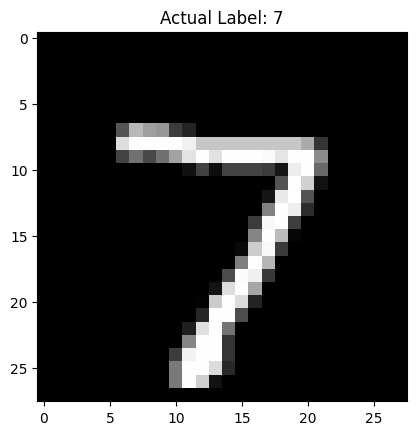

In [43]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Load MNIST test dataset
transform = transforms.Compose([transforms.ToTensor()])
test_data = datasets.MNIST(root="data", train=False, transform=transform, download=True)

# Select a sample image
image, label = test_data[0]  # First image from test dataset

# Show the image
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {label}")
plt.show()


In [44]:
# Add batch dimension and pass image through the model
image = image.unsqueeze(0)  # Model expects batch input (1, 1, 28, 28)

# Make prediction
with torch.no_grad():
    output = model(image)

# Get predicted class
predicted_class = torch.argmax(output, dim=1).item()

print(f"Predicted Label: {predicted_class}, Actual Label: {label}")

Predicted Label: 7, Actual Label: 7


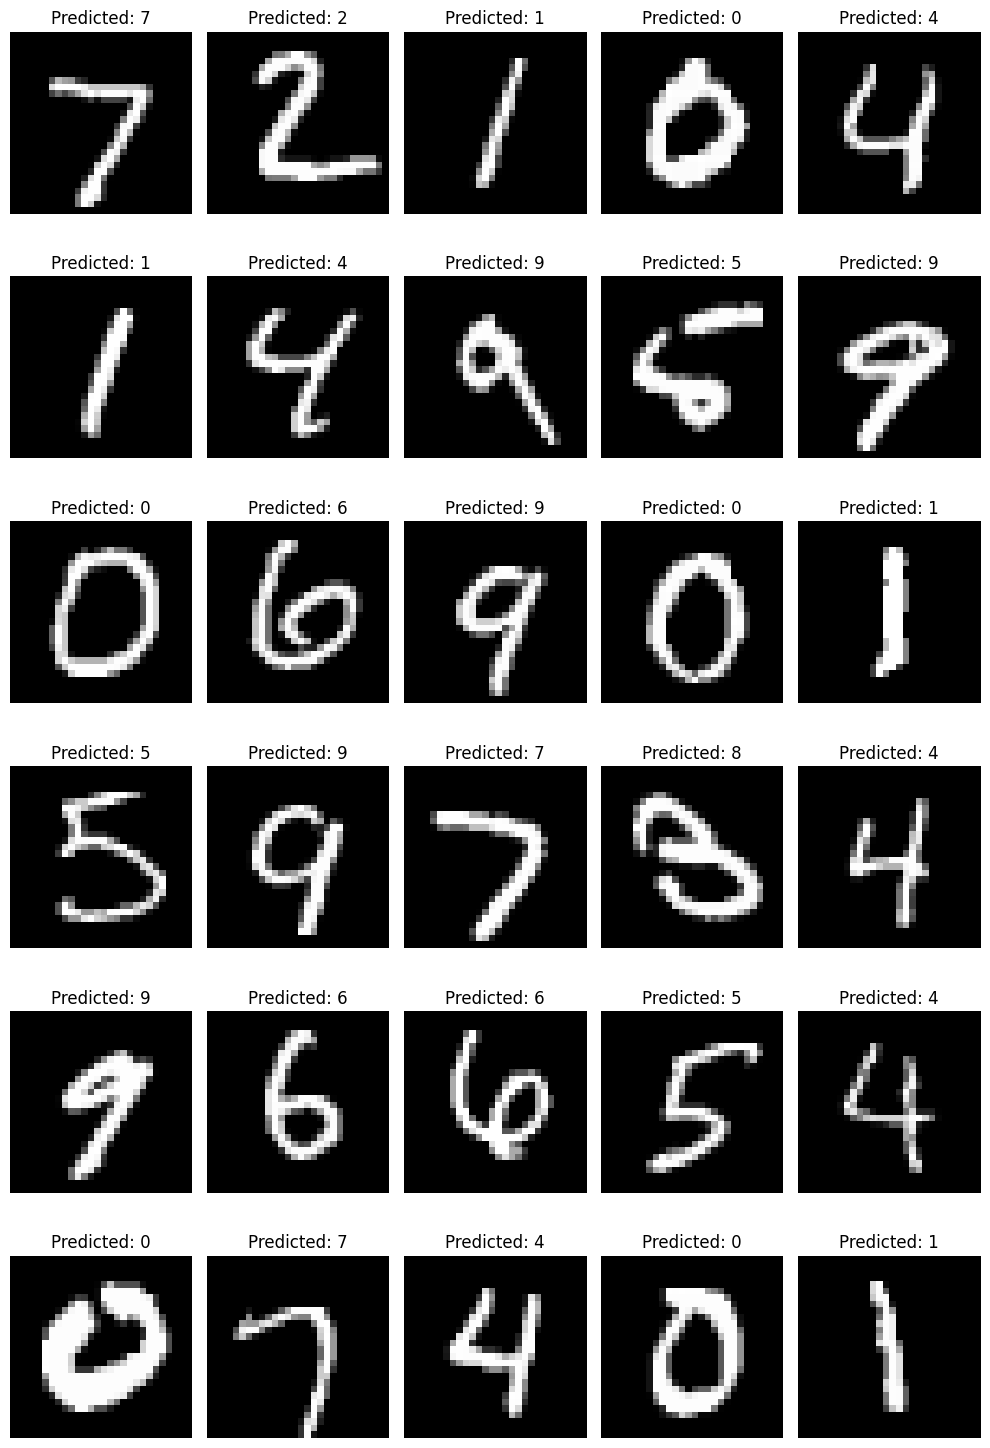

In [49]:
# Get a batch of data from the test set
xs, ys = next(iter(test_loader))  
xs = xs[:30]  # (selecting 30 images)

# Pass images through the model with correct input shape
with torch.no_grad():
    outputs = model(xs.view(xs.size(0), -1))  #  Flatten input
    yhats = outputs.argmax(dim=1)  

# Plot images with predictions
fig, ax = plt.subplots(6, 5, figsize=(10, 15))  #  Adjusted subplot grid

for i in range(30):
    plt.subplot(6, 5, i + 1)  #  Matches the number of images
    plt.imshow(xs[i].squeeze(), cmap="gray")  
    plt.title(f'Predicted: {yhats[i].item()}')
    plt.axis("off")

fig.tight_layout()
plt.show()
